In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
fold_Albertina = pd.read_csv("../../data/results/fold_results_Albertina.csv")
fold_BERTimbau = pd.read_csv("../../data/results/fold_results_BERTimbau.csv")
fold_mBERT = pd.read_csv("../../data/results/fold_results_mBERT.csv")
fold_RoBERTa = pd.read_csv("../../data/results/fold_results_XLM-RoBERTa.csv")

epochs_Albertina = pd.read_excel("../../data/results/Albertina_epochs.xlsx")

df_folds = pd.concat([
    fold_Albertina,
    fold_BERTimbau,
    fold_mBERT,
    fold_RoBERTa
], ignore_index=True)

metrics = [col for col in df_folds.columns if col not in ["model", "fold"]]

df_mean = df_folds.groupby("model")[metrics].mean()
df_std = df_folds.groupby("model")[metrics].std()

df_final = df_mean.copy()

for col in metrics:
    df_final[col] = df_mean[col].round(4).astype(str) + " ± " + df_std[col].round(4).astype(str)

df_final

,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_micro,eval_f1_weighted,eval_precision_macro,eval_precision_micro,eval_precision_weighted,eval_recall_macro,eval_recall_micro,eval_recall_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
model,,,,,,,,,,,,,,,
Albertina,0.0675 ± 0.0012,0.3853 ± 0.0068,0.431 ± 0.0082,0.5143 ± 0.0065,0.4857 ± 0.008,0.5369 ± 0.0064,0.6409 ± 0.0077,0.6096 ± 0.0095,0.392 ± 0.0068,0.4296 ± 0.0074,0.4296 ± 0.0074,86.3786 ± 6.819,100.9764 ± 8.211,6.3186 ± 0.5133,4.0 ± 0.0
BERTimbau,0.0678 ± 0.001,0.3874 ± 0.0074,0.3828 ± 0.0208,0.5158 ± 0.0074,0.4743 ± 0.009,0.5575 ± 0.0354,0.6761 ± 0.0077,0.6214 ± 0.0114,0.3308 ± 0.0193,0.417 ± 0.009,0.417 ± 0.009,16.7771 ± 0.099,517.2306 ± 3.0704,32.3662 ± 0.1905,4.0 ± 0.0
XLM-RoBERTa,0.0723 ± 0.0014,0.3108 ± 0.0042,0.2556 ± 0.0042,0.4499 ± 0.0038,0.3766 ± 0.0054,0.3617 ± 0.0264,0.7101 ± 0.0079,0.5275 ± 0.029,0.231 ± 0.0044,0.3292 ± 0.0029,0.3292 ± 0.0029,15.9257 ± 0.0852,544.8804 ± 2.8948,34.0966 ± 0.1814,4.0 ± 0.0
mBERT,0.0731 ± 0.0014,0.3294 ± 0.0066,0.2887 ± 0.0107,0.4631 ± 0.0051,0.3905 ± 0.0072,0.4354 ± 0.0242,0.6888 ± 0.0053,0.5148 ± 0.0351,0.2561 ± 0.0115,0.3488 ± 0.0051,0.3488 ± 0.0051,17.1841 ± 0.598,505.4512 ± 17.3847,31.6292 ± 1.0896,4.0 ± 0.0


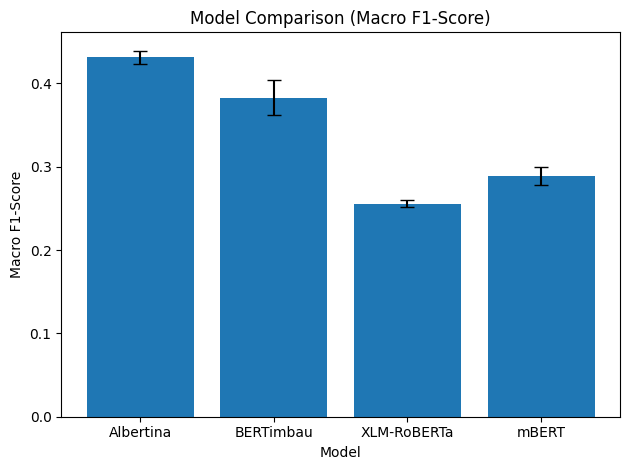

In [8]:
f1_mean = df_mean["eval_f1_macro"]
f1_std = df_std["eval_f1_macro"]

plt.figure()
plt.bar(f1_mean.index, f1_mean, yerr=f1_std, capsize=5)
plt.ylabel("Macro F1-Score")
plt.xlabel("Model")
plt.title("Model Comparison (Macro F1-Score)")
plt.tight_layout()
plt.show()

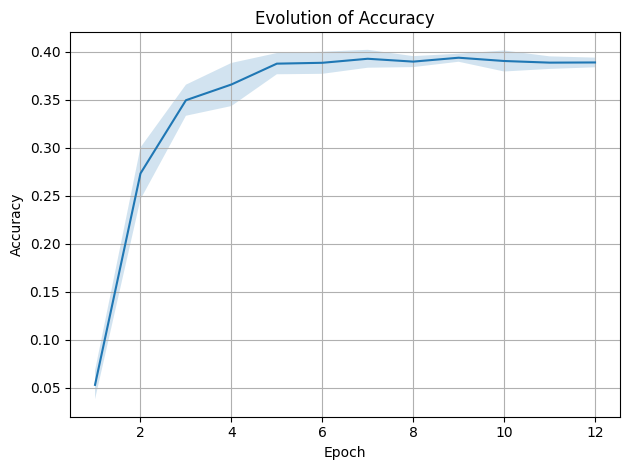

In [11]:
df_epochs = epochs_Albertina.copy()

grouped = df_epochs.groupby("EPOCH").agg({
    "ACCURACY": ["mean", "std"],
    "F1MACRO": ["mean", "std"]
})

grouped.columns = ["_".join(col) for col in grouped.columns]
grouped = grouped.reset_index()

plt.figure()
plt.plot(grouped["EPOCH"], grouped["ACCURACY_mean"])
plt.fill_between(
    grouped["EPOCH"],
    grouped["ACCURACY_mean"] - grouped["ACCURACY_std"],
    grouped["ACCURACY_mean"] + grouped["ACCURACY_std"],
    alpha=0.2
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolution of Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

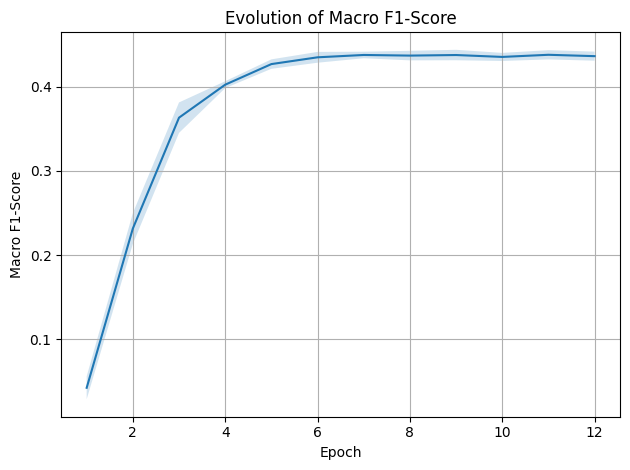

In [12]:
plt.figure()
plt.plot(grouped["EPOCH"], grouped["F1MACRO_mean"])
plt.fill_between(
    grouped["EPOCH"],
    grouped["F1MACRO_mean"] - grouped["F1MACRO_std"],
    grouped["F1MACRO_mean"] + grouped["F1MACRO_std"],
    alpha=0.2
)
plt.xlabel("Epoch")
plt.ylabel("Macro F1-Score")
plt.title("Evolution of Macro F1-Score")
plt.grid(True)
plt.tight_layout()
plt.show()